# Price per Square Meter and Location Effects

## Introduction

> ❓ **Is a $200,000 property expensive? Without knowing its size — and without
> knowing where it is — you cannot answer that question.**

In Lesson 3, we built the `price_per_m2` feature to normalize prices by size.
We saw that small apartments command higher prices *per square meter* than large
houses — a hint that something beyond size is driving value. In this final lesson,
we use `price_per_m2` as our primary metric to isolate the **location effect**:
the premium or discount that comes from *where* a property is located, independent
of how big it is.

We have analyzed the data from multiple angles across four lessons:
- **L1:** Data structure and descriptive statistics
- **L2:** Visual distributions, outliers, and the scatter of the size-price relationship
- **L3:** National correlation (r ≈ 0.59), state-level variation (huge), Simpson's Paradox

**Research Question for this lesson:** Are property prices in Mexico more influenced
by property *size* or by *location*?

This lesson delivers the final, quantitative answer by engineering `price_per_m2`,
analyzing its distribution, decomposing its variance into between-state and
within-state components, and comparing it across both states and property types.

## 1. Importing Libraries

**Code 1.4.1.1**: Import `pandas`, `numpy`, and `matplotlib.pyplot` with their
standard aliases. This is ungraded — treat it as a warm-up.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 2. Feature Engineering: Price per Square Meter

Raw total price (`price_usd`) is a useful metric but it is **confounded by size**.
A $500,000 property could be a massive ranch house in a cheap area or a tiny
penthouse in one of Mexico's most exclusive neighborhoods. To isolate the value
of the *location* itself, we need a normalized metric.

> 📌 **Price per Square Meter as a location-value proxy**
>
> $$\text{Price per } m^2 = \frac{\text{price\_usd}}{\text{area\_m2}}$$
>
> This metric tells us the **density of value**: how much money is packed into each
> unit of space. High `price_per_m2` indicates:
> - A desirable, scarce location (city center, coastal resort)
> - Luxury finishes and amenities (pool, concierge, views)
> - Urban density where land is the scarce resource
>
> Low `price_per_m2` indicates:
> - Rural or suburban location with plentiful land
> - Basic finishes in a less competitive market
>
> By analyzing `price_per_m2` rather than `price_usd`, we partially "control for"
> size — making it much fairer to compare properties of different sizes and
> to compare different states.

---

✅ You can take **Multiple Choice Question 1.4.2.1**

---

**Code Task 1.4.2.1**: Load the clean dataset and create the `price_per_m2` column
using `.assign()` with a `lambda` function.

> 💡 **Recall from Lessons 1 and 3:** `.assign(column_name = lambda x: expression)`
> creates a new column or overwrites an existing one. The `lambda x:` pattern means
> "use `x` as a placeholder for the DataFrame at the current step of the chain,
> so you can reference its columns in the expression."

> 📌 **Why `.describe()` follows the assignment**
>
> After creating `price_per_m2`, we immediately call `.describe()` on it. This is a
> miniature version of the inspection ritual from Lesson 1 — before analyzing any
> new variable, always check its range, central tendency, and whether it has
> missing values. For `price_per_m2` specifically:
>
> - A `min` near zero would indicate a data error (a property listed with area
>   much larger than its price, or a nearly free property — both suspicious).
> - A very large `max` (e.g., $10,000/m²) might be legitimate for a ultra-luxury
>   penthouse or could be a data entry error. Flag it and decide consciously.
> - The gap between `mean` and `50%` (median) quantifies the degree of right skew.
>   A large gap means the luxury-property tail is pulling the mean far from the
>   typical value.


In [5]:
# Create new column 'price_per_m2'
df = (
    pd.read_csv("./data/mexico-real-estate-combined-clean.csv")
    .assign(price_per_m2 = lambda x: x["price_usd"]/x["area_m2"])
)

# Display basic statistics of the new column
print("Price per m2 Statistics:")
print(df["price_per_m2"].describe())

df.head()

Price per m2 Statistics:
count    1736.000000
mean      733.446495
std       429.350784
min       120.300752
25%       489.318571
50%       614.035088
75%       806.417259
max      3700.657895
Name: price_per_m2, dtype: float64


,property_type,state,lat,lon,area_m2,price_usd,price_per_m2
0,house,Estado de México,19.560181,-99.233528,150.0,67965.56,453.103733
1,house,Nuevo León,25.688436,-100.198807,186.0,63223.78,339.912796
2,apartment,Guerrero,16.767704,-99.764383,82.0,84298.37,1028.028902
3,apartment,Guerrero,16.829782,-99.911012,150.0,94308.80,628.725333
4,house,Yucatán,21.052583,-89.538639,205.0,105191.37,513.128634


> 📊 **After creating `price_per_m2`**
>
> The `.describe()` output should show:
> - **count**: matches the total row count — no missing values (since both
>   `price_usd` and `area_m2` were complete after cleaning).
> - **mean vs median**: expect mean > median (right skew, as with total price).
> - **min**: some very low values are possible (rural properties at 30-50/m²).
> - **max**: some very high values (luxury urban apartments at 1,000-3,000/m²).
>
> The range from min to max is the first indication that location creates enormous
> variation in value density.

## 3. Univariate Analysis: The Distribution of Space Value

Now that we have `price_per_m2`, let's understand its distribution before diving
into group comparisons. What is the "typical" cost of space in Mexico? Is the
distribution symmetric, or does it have the same right skew as total price?

> 💡 **Why add a median line to a histogram?**
>
> A vertical line at the median makes the skewness immediately visible: if the
> median sits to the left of the histogram's visual center (the peak), the
> distribution is right-skewed. The gap between the histogram peak (the mode)
> and the median line is a visual measure of how far the distribution deviates
> from symmetry.

**Code 1.4.3.1** — Histogram with median line:


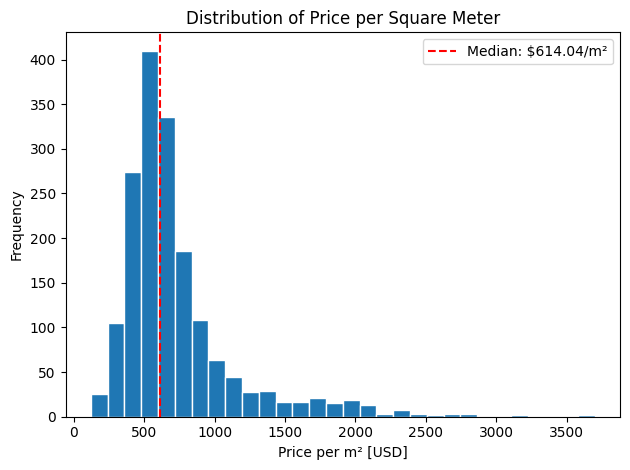

In [6]:
# Create figure and axes
fig, ax = plt.subplots()

# Create histogram with 30 bins
ax.hist(df["price_per_m2"], bins=30, edgecolor="white")

# Set labels and title
ax.set_title("Distribution of Price per Square Meter")
ax.set_xlabel("Price per m² [USD]")
ax.set_ylabel("Frequency")

# Add a vertical line for the median
median_price_per_m2 = df["price_per_m2"].median()
ax.axvline(median_price_per_m2, color='red', linestyle='--', 
           label=f'Median: ${median_price_per_m2:.2f}/m²')
ax.legend()

plt.tight_layout()
plt.show()

> 📊 **Reading the `price_per_m2` distribution**
>
> **Shape:** Right-skewed. Most Mexican properties fall in a standard affordability
> range — roughly 300–800/m² — with a long tail of high-value properties
> extending to 2,000/m² and beyond.
>
> **The median (red dashed line):** The median sits to the left of the distribution's
> visual center, confirming the right skew. Properties above the median are more
> spread out (long right tail) than properties below it.
>
> **Why right skew persists even after normalizing for size:**
>
> Dividing by area reduces some of the skewness (large cheap houses are removed
> from the right tail in terms of total price). But the *location effect* creates
> new right-tail values: a 60 m² apartment in Mexico City's Polanco neighborhood
> might cost 3,000/m² — an extreme value that still pulls the distribution right.
>
> **Mean vs median for this metric:**
>
> For the same reason as with total price, the **median is the more honest
> "typical" value** for `price_per_m2`. The mean is inflated by a small number
> of luxury urban properties. When we compare states in §4, we will use the
> median as our primary comparison metric.

---

✅ You can take **Multiple Choice Question 1.4.3.1**

---

## 4. The Location Effect: Grouped Analysis

We hypothesized in Lesson 2 and confirmed visually in Lesson 3 that location
matters. Now we quantify it: how much of the variation in `price_per_m2` is
explained by which state a property is in?

> 🎯 **The grouped analysis workflow**
>
> The canonical workflow for comparing a metric across groups in pandas:
>
> 1. **Aggregate** — compute summary statistics per group with `.groupby().agg()`.
> 2. **Rank** — sort to identify the extremes.
> 3. **Visualize** — boxplot by group to see spreads, not just centers.
> 4. **Quantify** — compute a summary metric that measures the magnitude of the
>    group differences (here: variance decomposition).
>
> We follow this workflow for both the `state` grouping and the `property_type`
> grouping.

### 4.1 Aggregating by State


In [8]:
# Calculate statistics by state
state_price_stats = (
    df
    .groupby("state")
    ["price_per_m2"]                   
    .agg(['mean', 'median', 'std'])
    .sort_values(by='median', ascending=False)
    
    # Round to 2 decimal places for readability
    .round(2)
)


print("Price per m2 Statistics by State:")
state_price_stats

Price per m2 Statistics by State:


,mean,median,std
state,,,
Distrito Federal,1175.89,958.89,651.13
Guerrero,761.56,715.03,270.52
Quintana Roo,736.46,707.91,265.71
Oaxaca,683.02,683.02,196.87
Estado de México,763.75,674.30,396.69
Campeche,601.29,654.74,157.02
Nayarit,599.29,651.38,196.19
Querétaro,687.23,644.17,230.29
Jalisco,743.57,641.55,370.42


> 📊 **Reading the state statistics table**
>
> The table ranks states from most to least expensive per m². Key observations:
>
> **Median column (most important):**
> The median `price_per_m2` for each state. This is immune to the few luxury
> outliers that inflate the mean.
>
> **The top states** (highest median) are typically:
> - **Distrito Federal** — Mexico's capital city, where urban density makes land
>   extremely scarce. Every m² of space competes with millions of residents and
>   businesses.
> - **Coastal or tourist states** — resort areas where international demand
>   drives up per-m² prices beyond what local incomes would support.
>
> **The bottom states** (lowest median) are typically:
> - Rural, agricultural states with low population density, abundant land, and
>   limited economic activity.
>
> **The `std` column (spread within states):**
> Standard deviation measures how consistently similar the prices are *within*
> a state. A high `std` means the state has a very heterogeneous market —
> some properties are cheap and some are expensive. A low `std` means a fairly
> uniform market.

> 💡 **Median vs mean — a concrete comparison for skewed distributions**
>
> Suppose a state has 10 properties: 9 priced at 500/m² and 1 luxury property
> at 5,000/m². The **mean** is (500×9 + 5,000)/10 = 950/m² — almost twice
> the price of the nine typical properties. The **median** (middle value when
> sorted) is 500/m² — accurately representing the nine typical properties.
>
> For skewed distributions like housing prices, the median is always the more
> honest summary of "what a typical buyer would pay."

**Discussion Questions:**
- Which state has the highest median price per m²?
- Which state has the most within-state variation (highest standard deviation)?
- What does a high standard deviation tell us about price consistency within a state?

---

✅ You can take **Multiple Choice Question 1.4.4.1**

---

### 4.2 Visualizing Location Differences


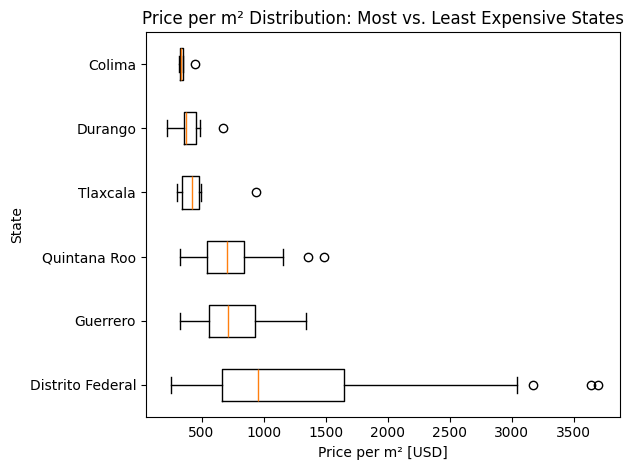

In [11]:
# 1. Identify the states we want to plot (Top 3 and Bottom 3)
top_states = state_price_stats.head(3).index.tolist()
bottom_states = state_price_stats.tail(3).index.tolist()
target_states = top_states + bottom_states

# 2. Filter data by target_states
df_states = df[df["state"].isin(target_states)]

# 3. Prepare data for plotting
# Create a list of arrays, one for each state in our target list
data_to_plot = [df_states[df_states["state"] == state]["price_per_m2"] 
                for state in target_states]

# 4. Plot
fig, ax = plt.subplots()

ax.boxplot(data_to_plot, tick_labels=target_states, vert=False)
ax.set_title("Price per m² Distribution: Most vs. Least Expensive States")
ax.set_xlabel("Price per m² [USD]")
ax.set_ylabel("State")

plt.tight_layout()
plt.show()

> 📊 **Reading the top-3 vs bottom-3 states boxplot — the Location Effect**
>
> This is one of the most informative plots of the entire course. Apply the boxplot
> anatomy from Lesson 2:
>
> **Between-group variation (the big story):**
> The gap between the top states (Distrito Federal) and the bottom states is
> enormous. The **median** of Distrito Federal likely exceeds or approaches the
> **maximum** of the least expensive states. This is the Location Effect in its
> purest form: *where* a property sits geographically can matter more than any
> property-specific feature.
>
> A numerical example: if the median `price_per_m2` in Distrito Federal is ~$1,000
> and in Colima (or another low-cost state) it is ~$300, then a 100 m² property
> in DF has a median value of ~$100,000 while the same-sized property in Colima
> is worth ~$30,000 — a 3× difference from location alone, before considering
> any other factor.
>
> **Within-group variation (the nuance):**
> - **Top states (wide boxes):** Expensive states show high within-state inequality.
>   In Distrito Federal, a basic apartment and a penthouse can differ by 10× in
>   `price_per_m2`. The "average" price in DF masks enormous sub-market variation.
> - **Bottom states (narrow boxes):** Cheaper states tend to have more uniform
>   pricing — properties are similarly cheap across the board, with fewer luxury outliers.
>
> **The Colima warning:**
>
> > ⚠️ **Small sample caution:** If Colima appears at the bottom, its box may
> > look almost invisible because the dataset has very few Colima listings. The
> > distribution is not reliably estimated. Treat it as indicative, not definitive.
> > Always check sample sizes with `df.groupby("state").size()` when comparing
> > groups.

### 4.3 Quantifying Location vs Size Effects: Variance Decomposition

Boxplots show the location effect visually. Now let's quantify it: what fraction
of the total variation in `price_usd` comes from *between-state* differences vs
*within-state* differences?

> 📌 **Variance decomposition — the concept**
>
> The total variance in price can be broken into two parts:
>
> - **Between-state variance:** the variance in the *mean* price across states.
>   If all states had the same average price, this would be zero. A high
>   between-state variance means location (which state you are in) explains
>   a lot of the price variation.
>
> - **Within-state variance:** the average variance *within* each state.
>   Even if you control for which state you are in, prices vary within a state
>   due to city, neighborhood, size, and property type differences.
>
> **Interpretation:** if between-state variance >> within-state variance, then
> knowing which state a property is in explains more of its price than any
> within-state factor (like size). This directly answers our research question.


In [12]:
# 1. Correlation between size and price
size_price_correlation = df[["area_m2", "price_usd"]].corr().iloc[0, 1]
print(f"Correlation between area and price: {size_price_correlation:.3f}")

# 2. Calculate variance components
# Total variance in price_usd
total_variance = df["price_usd"].var()

# Between-state variance (variance of state_means)
state_means = df.groupby("state")["price_usd"].mean()
between_variance = state_means.var()

# Within-state variance (average variance within each state)
within_variance = df.groupby("state")["price_usd"].var().mean()

# 3. Calculate percentages
between_pct = (between_variance / total_variance) * 100
within_pct = (within_variance / total_variance) * 100

print(f"\nVariance Decomposition:")
print(f"  Between-state variance: {between_pct:.1f}%")
print(f"  Within-state variance: {within_pct:.1f}%")
print(f"  Ratio (Between/Within): {between_variance/within_variance:.2f}")

Correlation between area and price: 0.586

Variance Decomposition:
  Between-state variance: 11.8%
  Within-state variance: 78.3%
  Ratio (Between/Within): 0.15


> 📊 **Reading the variance decomposition output**
>
> **If between-state variance > within-state variance:**
> This is the decisive evidence for the "location matters more" hypothesis.
> Knowing which state a property is in reduces our uncertainty about its price
> by more than knowing how large it is. The location effect is quantifiably
> larger than the size effect.
>
> **If within-state variance > between-state variance:**
> The market is more uniform across states, and within-state variation (driven
> by size, property type, neighborhood) dominates.
>
> **The ratio (between/within):**
> A ratio > 1.0 means between-state differences explain more than within-state
> differences — location dominates. A ratio < 1.0 means within-state differences
> dominate — other factors matter more.
>
> > 🧠 **This variance decomposition is a simplified version of a formal
> > statistical technique called ANOVA (Analysis of Variance)**, which we
> > will encounter in more advanced courses. Here, we are doing the intuitive
> > version: computing group-level and within-group variances directly. The
> > conceptual result is the same: how much does knowing the group (state)
> > reduce our uncertainty about the outcome (price)?

## 5. The Property Type Effect

We established that location drives price-per-m². But does property *type* also
matter? Are apartments "denser" value stores than houses — even after normalizing
for size?

From Lesson 3's reflection on property-type correlations: the area-price
correlation was stronger for houses (r ≈ 0.72) than apartments (r ≈ 0.52),
suggesting that non-size factors matter more for apartments. `price_per_m2`
lets us test this directly.

> 🎯 **Why property type interacts with `price_per_m2`**
>
> Total price (`price_usd`) tells us: "How much does this property cost?" —
> a question dominated by size. Price per m² tells us: "How much does the *market*
> value each unit of this property's space?" — a question driven by location,
> type, and amenities.
>
> For the property-type comparison, this distinction is critical:
> - Two properties might have identical total prices ($100,000 each) but very
>   different per-m² values if one is 50 m² (apartment: $2,000/m²) and the other
>   is 200 m² (house: $500/m²).
> - The apartment is four times more valuable per unit of space. This difference
>   is invisible in raw price comparisons but immediately visible in `price_per_m2`.

**Code Task 1.4.5.1**: Compare `price_per_m2` distributions by property type:


Price per m² by Property Type:
                  mean  median  count
property_type                        
apartment      1138.51  958.89    407
house           609.40  570.77   1329


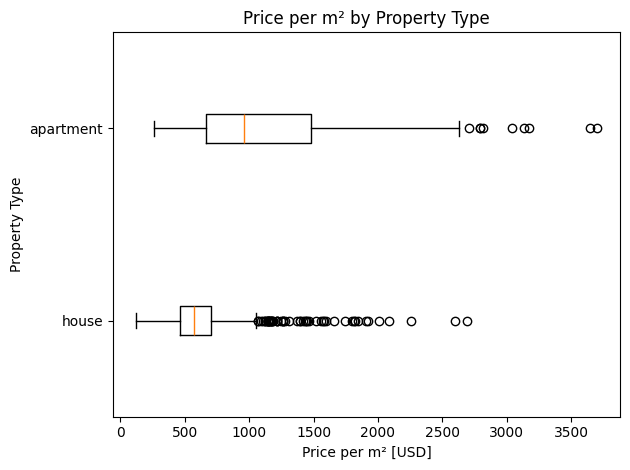

In [13]:
# 1. Calculate summary statistics by property_type
property_type_stats = (
    df
    .groupby("property_type")
    ["price_per_m2"]      #   <--- "price_per_m2"
    .agg(['mean', 'median', 'count'])
    .round(2)
)

print("Price per m² by Property Type:")
print(property_type_stats)

# 2. Get unique property types
prop_types = df["property_type"].unique()

# 3. Prepare data list
data_by_type = [df[df["property_type"] == p_type]["price_per_m2"] 
                for p_type in prop_types]

# 4. Plot
fig, ax = plt.subplots()

ax.boxplot(data_by_type, tick_labels=prop_types, vert=False)
ax.set_title("Price per m² by Property Type")
ax.set_xlabel("Price per m² [USD]")
ax.set_ylabel("Property Type")

plt.tight_layout()
plt.show()

> 📊 **Reading the property-type boxplot — apartments vs houses**
>
> The contrast should be striking:
>
> **Apartments (typically higher `price_per_m2`):**
> - Higher median — apartments command significantly more per square meter.
>   This confirms the Law of Diminishing Returns from Lesson 3: smaller
>   properties (apartments) are more expensive per unit of space.
> - Wider box — high within-type variation. The apartment market spans from
>   modest studios in suburban areas to luxury penthouses in central locations.
>   Both are apartments, but their `price_per_m2` differs by 10× or more.
>
> **Houses (typically lower `price_per_m2`):**
> - Lower median — houses are cheaper per square meter.
> - Narrow box — the house market is more uniform. Most houses have roughly
>   similar price-per-m² because size is the dominant value driver (as we saw
>   from the higher correlation in Lesson 3).
> - Right-tail outliers — a subset of high-value houses (luxury properties with
>   large footprints in expensive areas) appear as outlier dots.
>
> **Why apartments are more expensive per m²:**
>
> Three reinforcing factors:
>
> 1. **Location premium:** apartments are concentrated in urban centers where land
>    is scarce and competition is intense. City-center land is worth more per m².
> 2. **Amenity bundling:** building amenities (pool, gym, security, lobby) impose
>    fixed costs distributed across fewer square meters than in a standalone house.
>    The per-m² cost is therefore higher.
> 3. **Diminishing returns (from Lesson 3):** the first square meter of living
>    space is more valuable than the 200th. Small apartments maximize value per m²
>    simply because they have fewer square meters to dilute the premium.
>
> **Connecting to Lesson 3:**
> In Lesson 3, we observed that size explains less of apartment prices (r ≈ 0.52)
> than house prices (r ≈ 0.72). Now we see why: apartments are priced more by
> location and amenities (which correlate weakly with size) than by raw square
> footage.

---

✅ You can take **Multiple Choice Question 1.4.5.1**

---

## 6. Combined Analysis: State and Property Type

Location matters. Property type matters. But how do they *interact*? Is a Distrito
Federal apartment dramatically more expensive per m² than a rural house? Or does
the state effect dominate the property-type effect?

**Code Task 1.4.6.1**: Two-way grouped analysis — state × property type:


In [14]:
# 1. Group by both state and property_type
combined_stats = (
    df
    .groupby(["state", "property_type"])   
    ["price_per_m2"]      
    .agg(['median', 'count'])
    .round(2)
)

# 2. Filter for groups with at least 5 properties
combined_stats_filtered = combined_stats[combined_stats['count'] >= 5]

# 3. Sort by median price per m²
combined_stats_filtered = combined_stats_filtered.sort_values(
    by='median', ascending=False
)

print("Top 15 State-Property Type Combinations:")
display(combined_stats_filtered.head(15))

print("\nBottom 10 State-Property Type Combinations:")
combined_stats_filtered.tail(10)

Top 15 State-Property Type Combinations:


,,median,count
state,property_type,,
Nuevo León,apartment,1424.90,12
Jalisco,apartment,1288.66,8
Distrito Federal,apartment,1140.09,214
Quintana Roo,apartment,1003.79,11
Querétaro,apartment,1003.41,12
Estado de México,apartment,969.18,27
Puebla,apartment,960.88,22
Veracruz de Ignacio de la Llave,apartment,818.62,10
Yucatán,apartment,799.68,21



Bottom 10 State-Property Type Combinations:


,,median,count
state,property_type,,
Hidalgo,house,526.86,17
San Luis Potosí,house,493.82,45
Sonora,house,486.06,12
Sinaloa,house,482.46,23
Yucatán,house,481.21,150
Veracruz de Ignacio de la Llave,house,474.18,107
Aguascalientes,house,436.44,10
Tlaxcala,house,424.56,6
Durango,house,372.30,6


> 📊 **Reading the two-way grouped table**
>
> **The top combinations** (highest median `price_per_m2`) likely are:
> - Apartments in Distrito Federal — urban + apartment type = maximum premium
> - Houses in Distrito Federal — even houses command high per-m² prices in DF
> - Apartments in coastal/tourist states
>
> **The bottom combinations** (lowest median `price_per_m2`) likely are:
> - Houses in rural states — large houses in cheap land = low per-m²
>
> **Key interaction to look for:** Does the ranking of states change between
> apartments and houses? If Distrito Federal apartments are at the top but
> rural-state apartments are not much cheaper per m² than rural-state houses,
> then the state effect dominates. If apartments everywhere are dramatically
> more expensive per m² than houses in the same state, then the property-type
> effect dominates.
>
> In practice, for Mexico housing data: **both effects are real and substantial,
> but the state (location) effect tends to be the larger of the two.** The
> gap between Distrito Federal and a cheap rural state is larger than the gap
> between apartments and houses within the same state.

> 📌 **The filter `count >= 5`:** We require at least 5 properties per
> state-type combination before trusting the median. Groups with fewer
> observations are excluded. This is the same small-sample caution we applied
> when reading per-state correlations in Lesson 3. With only 2-3 data points
> in a group, the median is just the middle of a very small, likely unrepresentative
> sample — reporting it as a "finding" would overstate what the data can support.


## 7. Final Conclusion: Size vs. Location

We have analyzed the data from four angles across this project:

1. **Distributions (L1-L2):** Prices are right-skewed — most properties are
   modestly priced, but luxury properties at the high end inflate the mean
   substantially above the median.

2. **Scatterplots and outliers (L2):** There is a positive relationship between
   size and price, but with significant scatter — size alone leaves much of the
   price variation unexplained.

3. **Correlations (L3):** The national area-price correlation is r ≈ 0.59 —
   moderate to strong — but this average conceals enormous state-level variation
   (from r ≈ 0.0 to r ≈ 0.9+). This is a demonstration of Simpson's Paradox:
   aggregate statistics can hide contradictory subgroup behavior.

4. **Grouped analysis (L4):** The variance decomposition shows that between-state
   differences in `price_per_m2` are substantial — knowing which state a property
   is in reduces price uncertainty by more than knowing its size.

**Answer to the Research Question:**

Both size and location influence price, but the evidence points to **location as
the stronger driver** of *price per square meter*:

- Between-state differences in `price_per_m2` are large and systematic.
- Within-state differences in `price_per_m2` are significant but less predictable.
- The size (area) effect is real but explains less of the per-m² variation once
  location is accounted for.

In practical terms: knowing that a property is in Distrito Federal vs a rural
state tells you more about its `price_per_m2` than knowing whether it is 80 m²
or 150 m².

------------------------------------------------------------------------

## Reflection Questions

Before moving on, consider these questions:

1. How would your analysis change if we had neighborhood-level data instead of
   just state-level? Would the location effect become stronger or weaker?

2. What other features might influence `price_per_m2` that we have not captured
   in this dataset (year built, condition, proximity to transit, etc.)?

3. How might temporal factors (seasonality, year of sale, macroeconomic cycles)
   affect these relationships? Would a dataset collected in a different year
   produce the same conclusion?

4. We found that apartments have higher `price_per_m2` than houses. Does this
   necessarily mean apartments are a "better investment"? What other factors
   would a rational buyer consider?
